In [32]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm


In [33]:
# References
# https://datatas.com/how-to-use-variational-autoencoders-for-large-scale-data-compression/

In [34]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25

In [35]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    # print(encoded_width, encoded_height, np.log2(num_embeddings))
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total.astype(np.uint8)

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount) * encoded_patch_bits

# TODO: test the method
def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    
    total_bits = _get_total_hit_bits(n_hits_total)
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
    event_patches_adcs = [
        event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
        for event_patch_flat in event_patches_adcs_flat
    ]
    return len(event_patches_adcs)

    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [36]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:03<00:00, 280.15it/s]


In [37]:
batch_size = 64
beta = 1e-8
learning_rate = 1e-3
num_epochs = 120
channels = 1
latent_dim = 64

# Comment:
# Need to use bigger latent dimension. Bigger than 16. Wider latent dimension,
# the more information is preserved after matrix transformations
# If latent dimension = 16, than noisy outputs from encoder

# num_embeddings = 256 
LOG_EVERY = 10


In [38]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [39]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [40]:
event_train = events_train[:SELECTED_EVENTS][0]

In [41]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [42]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0], std=[1])    
])

event_dataset = PixelPatchesDataset(event_train, transform)

# Training data prepearation
train_loader = DataLoader(
    dataset=event_dataset, 
    batch_size=batch_size
)

# Test data preparation
# TODO: apply after the training examples are good
events_test_loaders = []
for event_test in events_test:
    event_dataset = PixelPatchesDataset(event_test, transform)

    event_test_loader = DataLoader(
        dataset=event_dataset, 
        batch_size=batch_size
    )
    events_test_loaders.append(event_test_loader)

In [43]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor, 
    mu: torch.tensor, 
    logvar: torch.tensor
) -> float:
    # recon_loss = F.mse_loss(
    #     recon_x, 
    #     x, 
    #     reduction="sum"
    # ) / x.size(0)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")
    
    # KL_divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    
    return (
        recon_loss + beta * kl_loss,
        recon_loss,
        beta,
        kl_loss
    )

In [44]:
class VAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.LeakyReLU(),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.LeakyReLU(),            
            nn.Conv2d(hidden_channels * 2, hidden_channels * 2, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.LeakyReLU(),
        )
        # self.flatten = nn.Flatten()
        self.fc_mean = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        self.fc_log_var = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        # self.fc_mean = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )
        torch.nn.init.xavier_uniform_(self.fc_mean.weight)
        
        # self.fc_log_var = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )        
        torch.nn.init.xavier_uniform_(self.fc_log_var.weight)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.LeakyReLU(),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        x_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        z_log_mean = self.fc_mean(x_encoded)
        z_log_var = self.fc_log_var(x_encoded)
        
        self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        self.z_log_var = torch.clamp(z_log_var, min=-4, max=1)
        
        # sample a latent vector using the reparameterization trick
        
        z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        output = self.decoder(z)
        
        return output, self.z_log_mean, self.z_log_var

In [45]:
model = VAE(
    hidden_channels=32, 
    kernel_size = 4
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/120: 100%|██████████| 248/248 [00:00<00:00, 662.71it/s, Loss=182]


Epoch [1/120] Average Loss: 821.1796
Before compression
Before: (64, 8, 8)


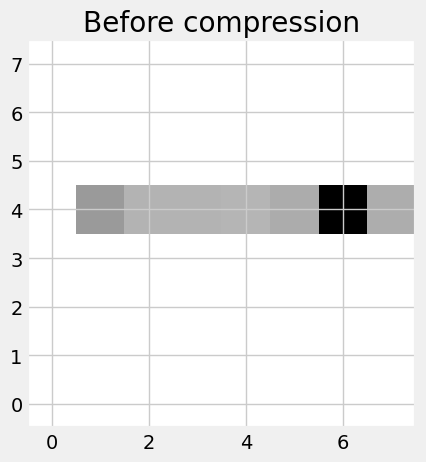

mu: mean=-1.2282, std=9.3873 | logvar: mean=-0.0498, std=1.9256
Loss statistics:
recon=181.8380, kl=566407.4375, beta_kl=0.0057
After: (1, 8, 8)
After compression


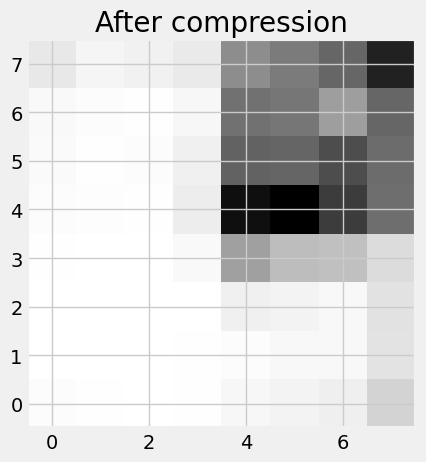

Epoch 2/120: 100%|██████████| 248/248 [00:00<00:00, 658.25it/s, Loss=152]


Epoch [2/120] Average Loss: 226.6904


Epoch 3/120: 100%|██████████| 248/248 [00:00<00:00, 656.34it/s, Loss=144]


Epoch [3/120] Average Loss: 207.9547


Epoch 4/120: 100%|██████████| 248/248 [00:00<00:00, 663.38it/s, Loss=143]


...

Epoch [9/120] Average Loss: 187.4786


Epoch 10/120: 100%|██████████| 248/248 [00:00<00:00, 696.66it/s, Loss=165]


Epoch [10/120] Average Loss: 190.0265


Epoch 11/120: 100%|██████████| 248/248 [00:00<00:00, 718.23it/s, Loss=168]


Epoch [11/120] Average Loss: 188.0536
Before compression
Before: (64, 8, 8)


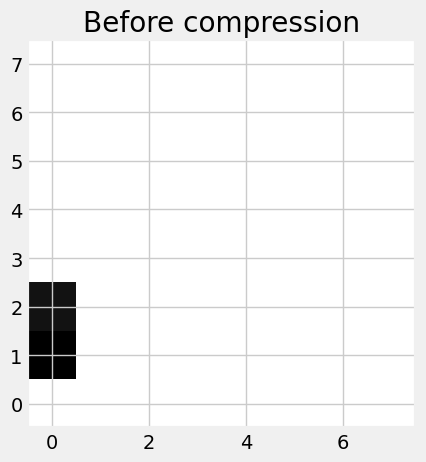

mu: mean=-0.9840, std=9.4060 | logvar: mean=-0.8327, std=2.3724
Loss statistics:
recon=167.5108, kl=560306.6250, beta_kl=0.0056
After: (1, 8, 8)
After compression


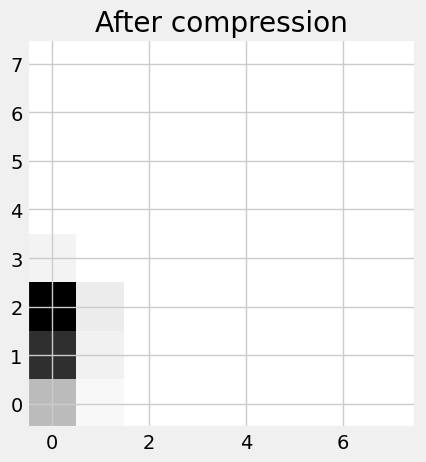

Epoch 12/120: 100%|██████████| 248/248 [00:00<00:00, 711.17it/s, Loss=120]


Epoch [12/120] Average Loss: 184.2306


Epoch 13/120: 100%|██████████| 248/248 [00:00<00:00, 684.18it/s, Loss=124] 


Epoch [13/120] Average Loss: 180.0909


Epoch 14/120: 100%|██████████| 248/248 [00:00<00:00, 692.04it/s, Loss=119] 


...

Epoch [19/120] Average Loss: 168.7936


Epoch 20/120: 100%|██████████| 248/248 [00:00<00:00, 687.76it/s, Loss=115] 


Epoch [20/120] Average Loss: 168.6337


Epoch 21/120: 100%|██████████| 248/248 [00:00<00:00, 705.25it/s, Loss=155] 


Epoch [21/120] Average Loss: 166.2858
Before compression
Before: (64, 8, 8)


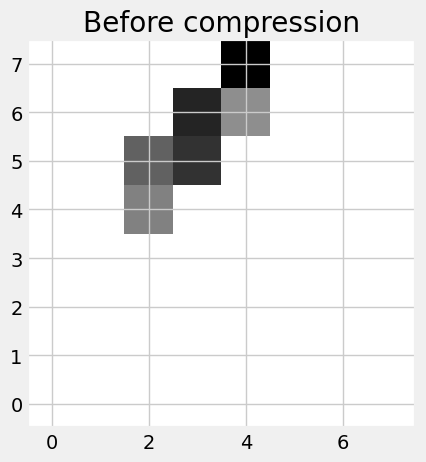

mu: mean=-0.9066, std=9.2805 | logvar: mean=-1.2482, std=2.4224
Loss statistics:
recon=155.3817, kl=560056.0000, beta_kl=0.0056
After: (1, 8, 8)
After compression


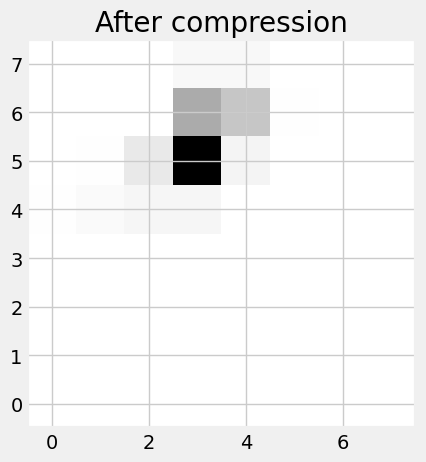

Epoch 22/120: 100%|██████████| 248/248 [00:00<00:00, 670.99it/s, Loss=114] 


Epoch [22/120] Average Loss: 163.4959


Epoch 23/120: 100%|██████████| 248/248 [00:00<00:00, 668.20it/s, Loss=112] 


Epoch [23/120] Average Loss: 160.4221


Epoch 24/120: 100%|██████████| 248/248 [00:00<00:00, 665.44it/s, Loss=120] 


...

Epoch [29/120] Average Loss: 158.2996


Epoch 30/120: 100%|██████████| 248/248 [00:00<00:00, 657.57it/s, Loss=105] 


Epoch [30/120] Average Loss: 152.2826


Epoch 31/120: 100%|██████████| 248/248 [00:00<00:00, 646.43it/s, Loss=106] 


Epoch [31/120] Average Loss: 152.6413
Before compression
Before: (64, 8, 8)


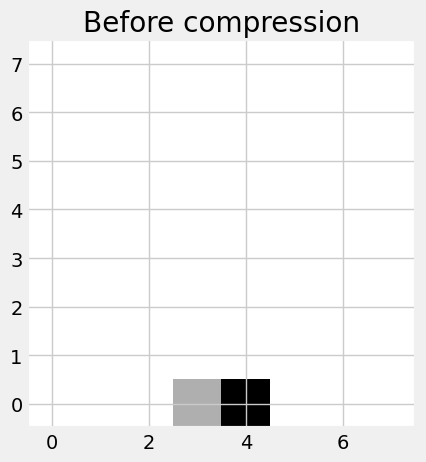

mu: mean=-0.6473, std=9.1842 | logvar: mean=-1.6339, std=2.4291
Loss statistics:
recon=105.7195, kl=554046.5000, beta_kl=0.0055
After: (1, 8, 8)
After compression


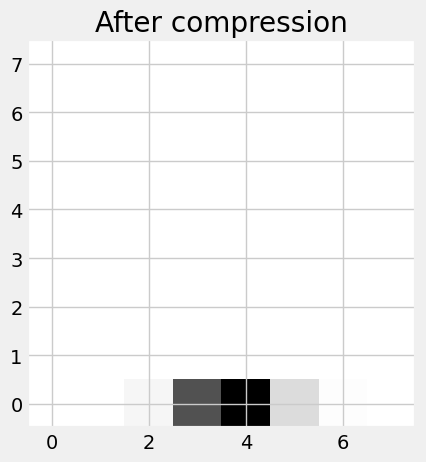

Epoch 32/120: 100%|██████████| 248/248 [00:00<00:00, 666.43it/s, Loss=105] 


Epoch [32/120] Average Loss: 151.5214


Epoch 33/120: 100%|██████████| 248/248 [00:00<00:00, 672.76it/s, Loss=105] 


Epoch [33/120] Average Loss: 149.5114


Epoch 34/120: 100%|██████████| 248/248 [00:00<00:00, 687.64it/s, Loss=104] 


...

Epoch [39/120] Average Loss: 146.6419


Epoch 40/120: 100%|██████████| 248/248 [00:00<00:00, 664.36it/s, Loss=108] 


Epoch [40/120] Average Loss: 144.1130


Epoch 41/120: 100%|██████████| 248/248 [00:00<00:00, 666.51it/s, Loss=103] 


Epoch [41/120] Average Loss: 144.9811
Before compression
Before: (64, 8, 8)


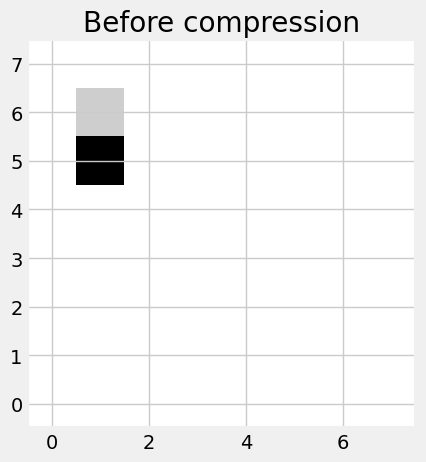

mu: mean=-0.6385, std=9.3405 | logvar: mean=-2.0465, std=2.3968
Loss statistics:
recon=102.8601, kl=545222.2500, beta_kl=0.0055
After: (1, 8, 8)
After compression


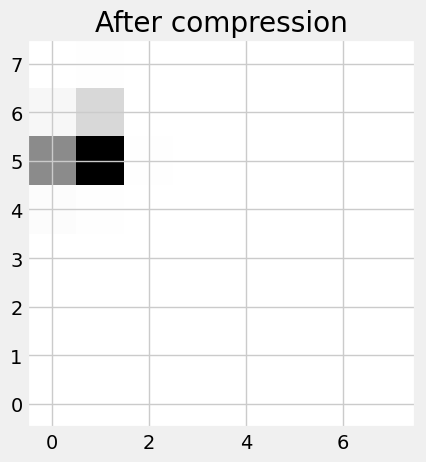

Epoch 42/120: 100%|██████████| 248/248 [00:00<00:00, 672.00it/s, Loss=106] 


Epoch [42/120] Average Loss: 144.9818


Epoch 43/120: 100%|██████████| 248/248 [00:00<00:00, 674.61it/s, Loss=104] 


Epoch [43/120] Average Loss: 143.4505


Epoch 44/120: 100%|██████████| 248/248 [00:00<00:00, 673.67it/s, Loss=104] 


...

Epoch [49/120] Average Loss: 140.2235


Epoch 50/120: 100%|██████████| 248/248 [00:00<00:00, 682.53it/s, Loss=98.9]


Epoch [50/120] Average Loss: 140.2815


Epoch 51/120: 100%|██████████| 248/248 [00:00<00:00, 675.25it/s, Loss=99.8]


Epoch [51/120] Average Loss: 137.8140
Before compression
Before: (64, 8, 8)


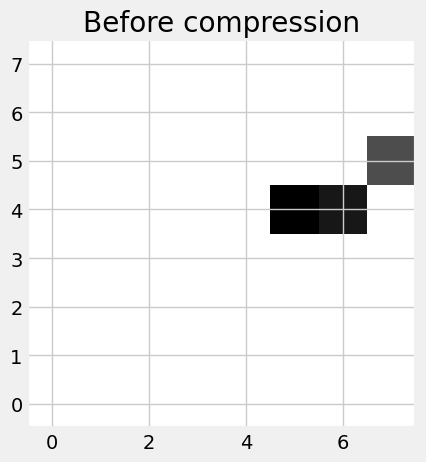

mu: mean=-0.6748, std=9.2153 | logvar: mean=-2.2749, std=2.3102
Loss statistics:
recon=99.8318, kl=541595.2500, beta_kl=0.0054
After: (1, 8, 8)
After compression


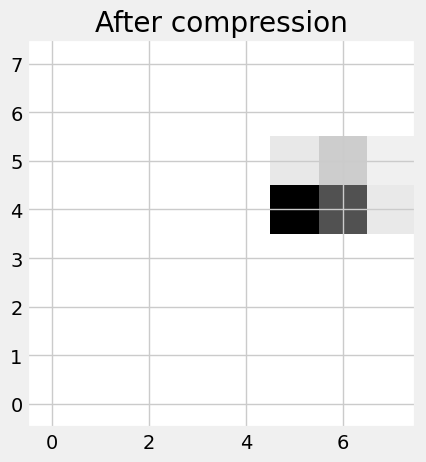

Epoch 52/120: 100%|██████████| 248/248 [00:00<00:00, 686.95it/s, Loss=98.3]


Epoch [52/120] Average Loss: 137.1206


Epoch 53/120: 100%|██████████| 248/248 [00:00<00:00, 704.66it/s, Loss=98.7]


Epoch [53/120] Average Loss: 138.5615


Epoch 54/120: 100%|██████████| 248/248 [00:00<00:00, 690.77it/s, Loss=98.9]


...

Epoch [59/120] Average Loss: 136.6178


Epoch 60/120: 100%|██████████| 248/248 [00:00<00:00, 702.51it/s, Loss=97.9]


Epoch [60/120] Average Loss: 135.7208


Epoch 61/120: 100%|██████████| 248/248 [00:00<00:00, 672.78it/s, Loss=99.6]


Epoch [61/120] Average Loss: 134.1461
Before compression
Before: (64, 8, 8)


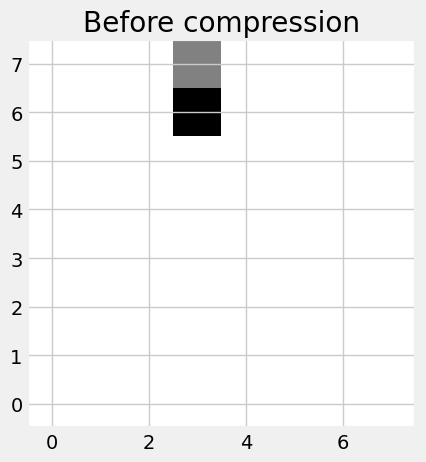

mu: mean=-0.6246, std=9.0606 | logvar: mean=-2.2455, std=2.2973
Loss statistics:
recon=99.6248, kl=537427.2500, beta_kl=0.0054
After: (1, 8, 8)
After compression


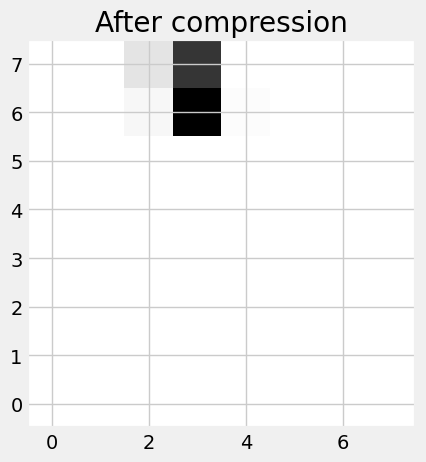

Epoch 62/120: 100%|██████████| 248/248 [00:00<00:00, 650.14it/s, Loss=96.1]


Epoch [62/120] Average Loss: 135.3124


Epoch 63/120: 100%|██████████| 248/248 [00:00<00:00, 677.24it/s, Loss=98.5]


Epoch [63/120] Average Loss: 133.7499


Epoch 64/120: 100%|██████████| 248/248 [00:00<00:00, 685.09it/s, Loss=97]  


...

Epoch [69/120] Average Loss: 133.6452


Epoch 70/120: 100%|██████████| 248/248 [00:00<00:00, 681.80it/s, Loss=95.5]


Epoch [70/120] Average Loss: 133.1368


Epoch 71/120: 100%|██████████| 248/248 [00:00<00:00, 651.45it/s, Loss=96.1]


Epoch [71/120] Average Loss: 133.7886
Before compression
Before: (64, 8, 8)


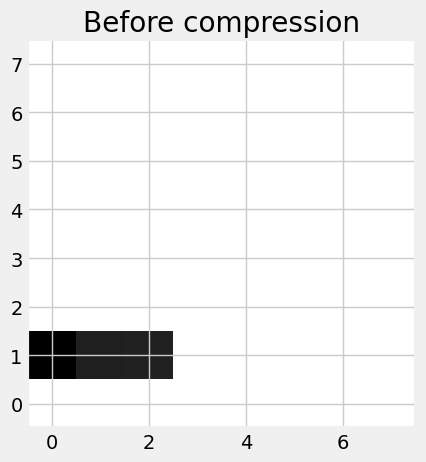

mu: mean=-0.6274, std=9.0151 | logvar: mean=-2.2598, std=2.2645
Loss statistics:
recon=96.1199, kl=533009.8750, beta_kl=0.0053
After: (1, 8, 8)
After compression


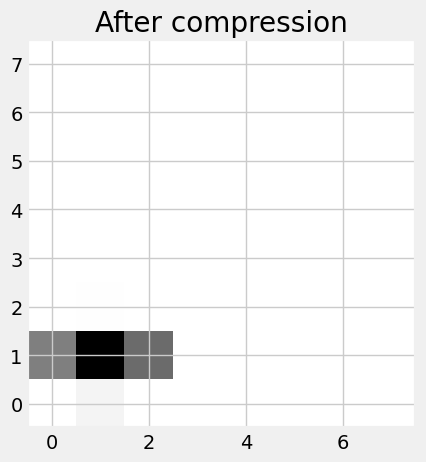

Epoch 72/120: 100%|██████████| 248/248 [00:00<00:00, 667.46it/s, Loss=97.5]


Epoch [72/120] Average Loss: 133.4863


Epoch 73/120: 100%|██████████| 248/248 [00:00<00:00, 683.17it/s, Loss=95.6]


Epoch [73/120] Average Loss: 131.6010


Epoch 74/120: 100%|██████████| 248/248 [00:00<00:00, 679.41it/s, Loss=95.7]


...

Epoch [79/120] Average Loss: 129.5416


Epoch 80/120: 100%|██████████| 248/248 [00:00<00:00, 693.97it/s, Loss=97.2]


Epoch [80/120] Average Loss: 132.6219


Epoch 81/120: 100%|██████████| 248/248 [00:00<00:00, 709.54it/s, Loss=95.1]


Epoch [81/120] Average Loss: 130.8495
Before compression
Before: (64, 8, 8)


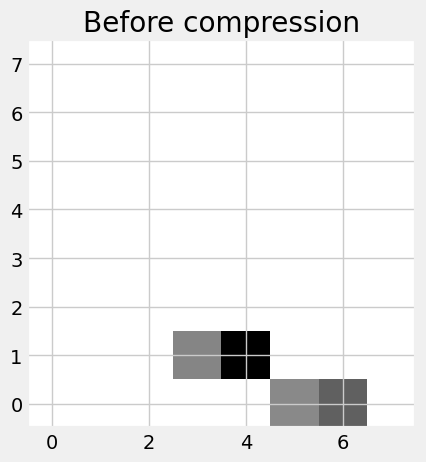

mu: mean=-0.5624, std=9.0447 | logvar: mean=-2.4291, std=2.2408
Loss statistics:
recon=95.0887, kl=529874.6250, beta_kl=0.0053
After: (1, 8, 8)
After compression


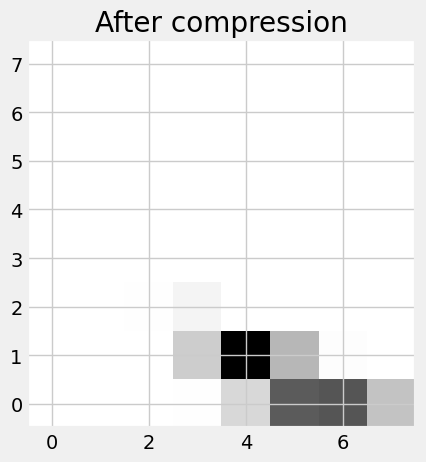

Epoch 82/120: 100%|██████████| 248/248 [00:00<00:00, 700.58it/s, Loss=94.5]


Epoch [82/120] Average Loss: 130.6097


Epoch 83/120: 100%|██████████| 248/248 [00:00<00:00, 685.40it/s, Loss=98.3]


Epoch [83/120] Average Loss: 128.7062


Epoch 84/120: 100%|██████████| 248/248 [00:00<00:00, 680.37it/s, Loss=97.7]


...

Epoch [89/120] Average Loss: 129.1021


Epoch 90/120: 100%|██████████| 248/248 [00:00<00:00, 672.95it/s, Loss=95.2]


Epoch [90/120] Average Loss: 128.4493


Epoch 91/120: 100%|██████████| 248/248 [00:00<00:00, 675.88it/s, Loss=94.3]


Epoch [91/120] Average Loss: 127.3052
Before compression
Before: (64, 8, 8)


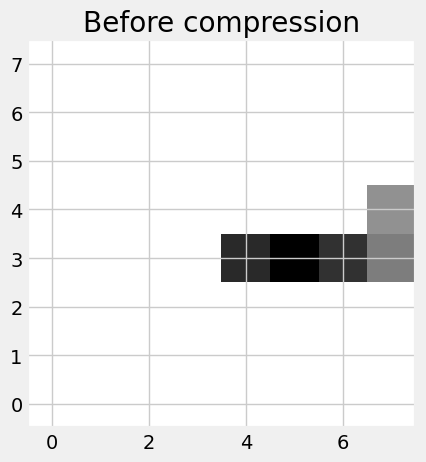

mu: mean=-0.6294, std=9.1493 | logvar: mean=-2.6966, std=2.1060
Loss statistics:
recon=94.3122, kl=529613.8125, beta_kl=0.0053
After: (1, 8, 8)
After compression


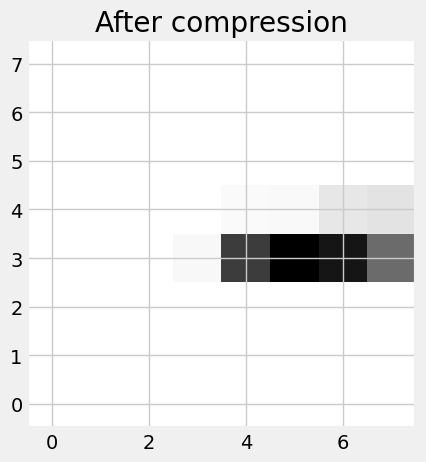

Epoch 92/120: 100%|██████████| 248/248 [00:00<00:00, 677.70it/s, Loss=101] 


Epoch [92/120] Average Loss: 127.5126


Epoch 93/120: 100%|██████████| 248/248 [00:00<00:00, 684.02it/s, Loss=94.8]


Epoch [93/120] Average Loss: 127.8199


Epoch 94/120: 100%|██████████| 248/248 [00:00<00:00, 680.64it/s, Loss=93.7]


...

Epoch [99/120] Average Loss: 126.4278


Epoch 100/120: 100%|██████████| 248/248 [00:00<00:00, 682.06it/s, Loss=94]  


Epoch [100/120] Average Loss: 125.9625


Epoch 101/120: 100%|██████████| 248/248 [00:00<00:00, 658.73it/s, Loss=93.9]


Epoch [101/120] Average Loss: 128.0643
Before compression
Before: (64, 8, 8)


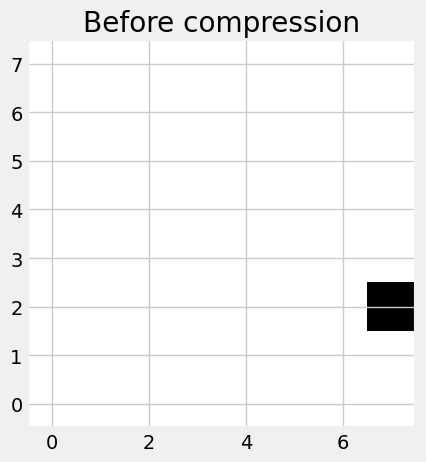

mu: mean=-0.6862, std=9.0512 | logvar: mean=-2.7087, std=2.0961
Loss statistics:
recon=93.8927, kl=527758.7500, beta_kl=0.0053
After: (1, 8, 8)
After compression


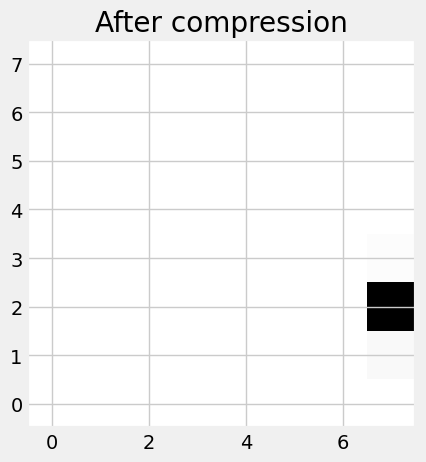

Epoch 102/120: 100%|██████████| 248/248 [00:00<00:00, 667.24it/s, Loss=95.4]


Epoch [102/120] Average Loss: 128.0842


Epoch 103/120: 100%|██████████| 248/248 [00:00<00:00, 659.21it/s, Loss=94.8]


Epoch [103/120] Average Loss: 127.9164


Epoch 104/120: 100%|██████████| 248/248 [00:00<00:00, 659.70it/s, Loss=94.4]


...

Epoch [109/120] Average Loss: 126.3948


Epoch 110/120: 100%|██████████| 248/248 [00:00<00:00, 665.40it/s, Loss=127] 


Epoch [110/120] Average Loss: 126.3446


Epoch 111/120: 100%|██████████| 248/248 [00:00<00:00, 666.96it/s, Loss=92.5]


Epoch [111/120] Average Loss: 126.2560
Before compression
Before: (64, 8, 8)


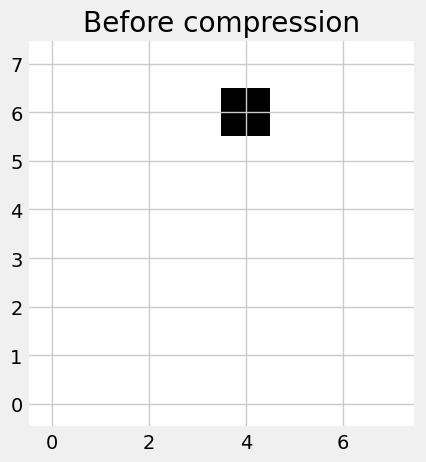

mu: mean=-0.6119, std=8.9375 | logvar: mean=-2.7130, std=2.0913
Loss statistics:
recon=92.4945, kl=524528.2500, beta_kl=0.0052
After: (1, 8, 8)
After compression


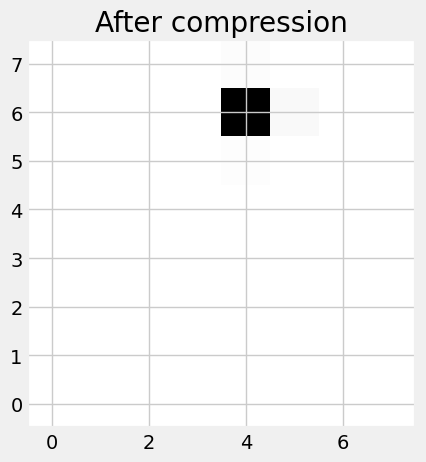

Epoch 112/120: 100%|██████████| 248/248 [00:00<00:00, 665.50it/s, Loss=95.6]


Epoch [112/120] Average Loss: 125.2246


Epoch 113/120: 100%|██████████| 248/248 [00:00<00:00, 666.73it/s, Loss=92.6]


Epoch [113/120] Average Loss: 125.4659


Epoch 114/120: 100%|██████████| 248/248 [00:00<00:00, 661.81it/s, Loss=95.2]


...

Epoch [118/120] Average Loss: 124.1246


Epoch 119/120: 100%|██████████| 248/248 [00:00<00:00, 659.78it/s, Loss=93]  


Epoch [119/120] Average Loss: 124.7860


Epoch 120/120: 100%|██████████| 248/248 [00:00<00:00, 672.67it/s, Loss=93]  

Epoch [120/120] Average Loss: 123.3842


In [46]:
average_loss = []
patches_before = []
patches_after = []

patch_test_cursor = iter(events_test_loaders[0])
model.train()

for epoch in range(num_epochs):
    train_loss = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        
        # Adding some randomness for regulating the small noisy areas
        # X_adcs = X_adcs + 0.01 * torch.randn_like(X_adcs)
        
        X_adcs = X_adcs.to(device)
        
    
        (
            recon_patch, 
            mu,
            logvar 
        ) = model(
           X_adcs
        )
        
        loss, recon_loss, beta, kl_loss = _get_vae_loss(recon_patch, X_adcs, mu, logvar)
        
        recon_patch = recon_patch.float().to(device)      
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        
        train_loss += loss.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
        
    # Saving epoch  statistics
    
    avg_loss = train_loss / len(train_loader)
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')
    average_loss.append(avg_loss)
    
    if epoch % LOG_EVERY == 0:
        with torch.no_grad():            
            # selecting events before reconstruction using one test loader as validation
            patch_test = next(patch_test_cursor) 
            patch_test = patch_test.to(device)           
            print("Before compression")
            
            patch_test_ts = _tensor_to_numpy(
                patch_test.squeeze(1)
            )
            
            print(f"Before: {patch_test_ts.shape}")            
            plot_patch(patch_test_ts[0], "Before compression")
            
            patches_before.append(patch_test_ts[0])
            
            (
                recon_patch, 
                mu,
                logvar 
            ) = model(patch_test)
            
            print(
                f"mu: mean={mu.mean().item():.4f}, std={mu.std().item():.4f} | "
                f"logvar: mean={logvar.mean().item():.4f}, std={logvar.std().item():.4f}"
            )
            
            print("Loss statistics:")
            print(
                f"recon={recon_loss.item():.4f}, "
                f"kl={kl_loss.item():.4f}, "
                f"beta_kl={(beta * kl_loss).item():.4f}"
            )
            
            recon_patch_np = _tensor_to_numpy(
                recon_patch[0]
            )
            print(f"After: {recon_patch_np.shape}")
            print("After compression")
            
            plot_patch(recon_patch_np[0], "After compression")
            
            patches_after.append(recon_patch_np[0])
        

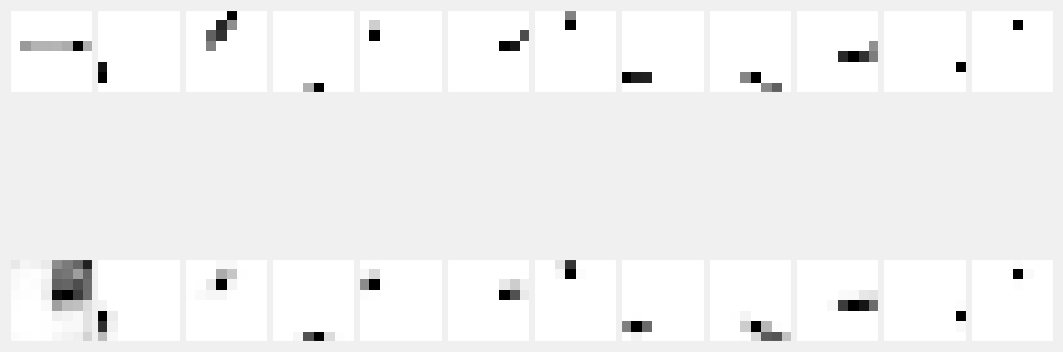

In [47]:
image_rows = [
    patches_before,
    patches_after
]
cols = len(image_rows[0])
rows = len(image_rows)

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i in range(rows):
    for j in range(cols):
        ax = axes[i, j]
        ax.imshow(image_rows[i][j], cmap='gist_yarg', origin='lower')
        
        ax.set_xticks([])
        ax.set_yticks([])
        
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

In [48]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.329310804605484
encoder.2.weight 0.1988765001296997
encoder.4.weight 0.3311457633972168
fc_mean.weight 3.427034854888916
fc_mean.bias 0.04418311268091202
fc_log_var.weight 0.011225320398807526
fc_log_var.bias 0.00027952640084549785
decoder.0.weight 0.9961273670196533
decoder.2.weight 1.4239917993545532
decoder.4.weight 3.1584298610687256


/tmp/ipykernel_2970954/1764288248.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


VAE, Average loss values over epochs


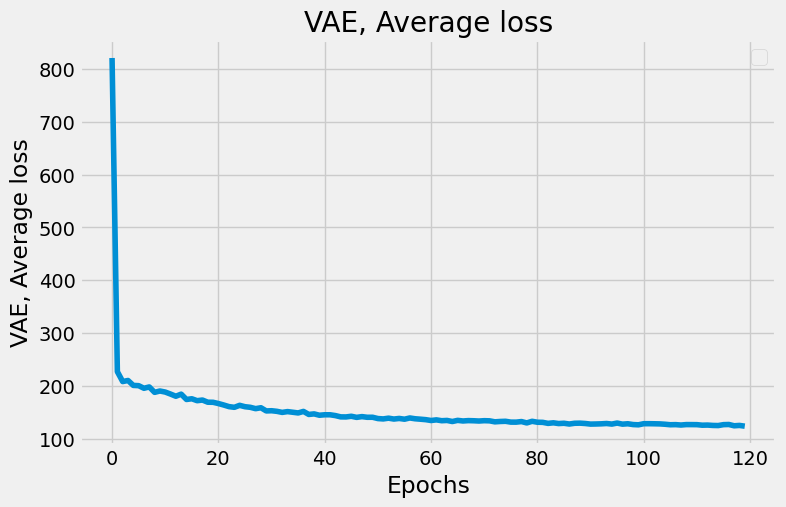

In [49]:
# display loss values
plot_metric_results(
    y_values=average_loss, 
    x_values=list(range(num_epochs)),
    y_title="VAE, Average loss",
    title="VAE, Average loss",
    x_label="Epochs"
)

In [50]:
print(f"mu = {model.z_log_mean.mean().item()}")
print(f"logvar = {model.z_log_var.std().item()}")

mu = -0.6459048390388489
logvar = 1.9772688150405884
